In [7]:
# cargamos las librerías
import cv2
import matplotlib.pyplot as plt
import numpy as np


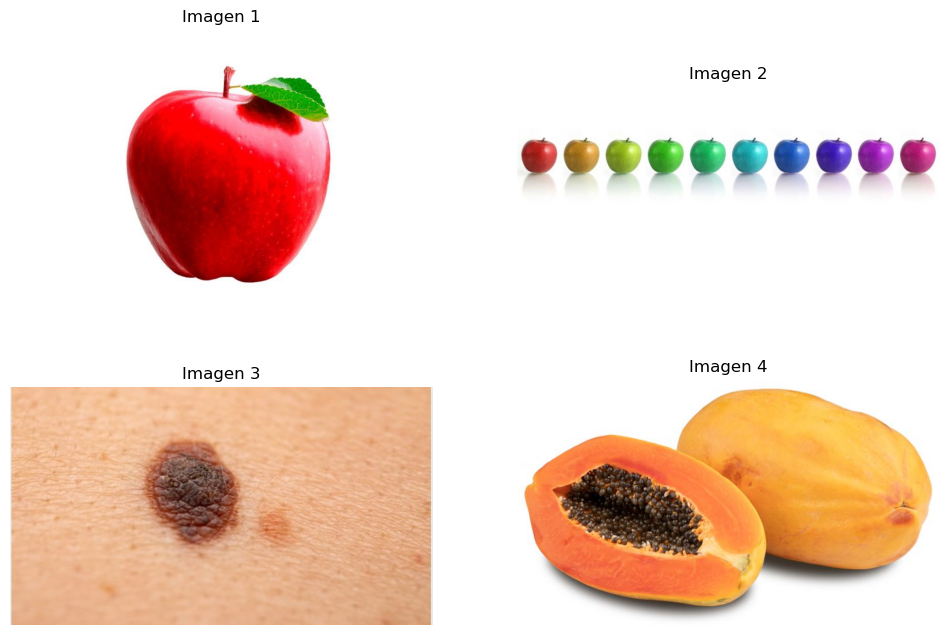

In [8]:
# 1. CARGA DE IMÁGENES
# Reemplaza los nombres de archivo por los que tengas en tu carpeta
img1 = cv2.imread("reales/manzana.jpeg")
img2 = cv2.imread("reales/manzanitas.jpeg")
img3 = cv2.imread("reales/melanoma.jpeg")
img4 = cv2.imread("reales/papaya.jpeg")

imagenes = [img1, img2, img3, img4]
nombres = ["Imagen 1", "Imagen 2", "Imagen 3", "Imagen 4"]

# las pasamos bgr a rgb
imagenes_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in imagenes]

plt.figure(figsize=(12, 8))
for i, img in enumerate(imagenes_rgb):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(nombres[i])
    plt.axis("off")

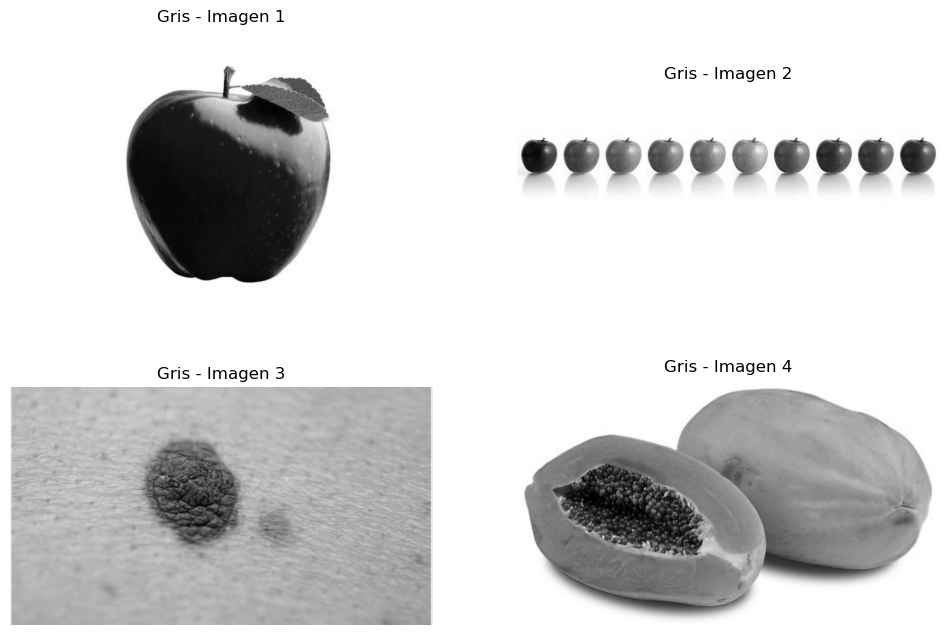

In [9]:
# 2. PROCESAMIENTO INICIAL (Grises y Vectores)
grises = []
vectores = []

for i, img in enumerate(imagenes_rgb):
    # Convertir a escala de grises
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grises.append(gris)
    
    # Aplanar la imagen a un vector
    vector = gris.flatten()
    vectores.append(vector)

plt.figure(figsize=(12, 8))
for i, gris in enumerate(grises):
    plt.subplot(2, 2, i + 1)
    plt.imshow(gris, cmap="gray")
    plt.title(f"Gris - {nombres[i]}")
    plt.axis("off")

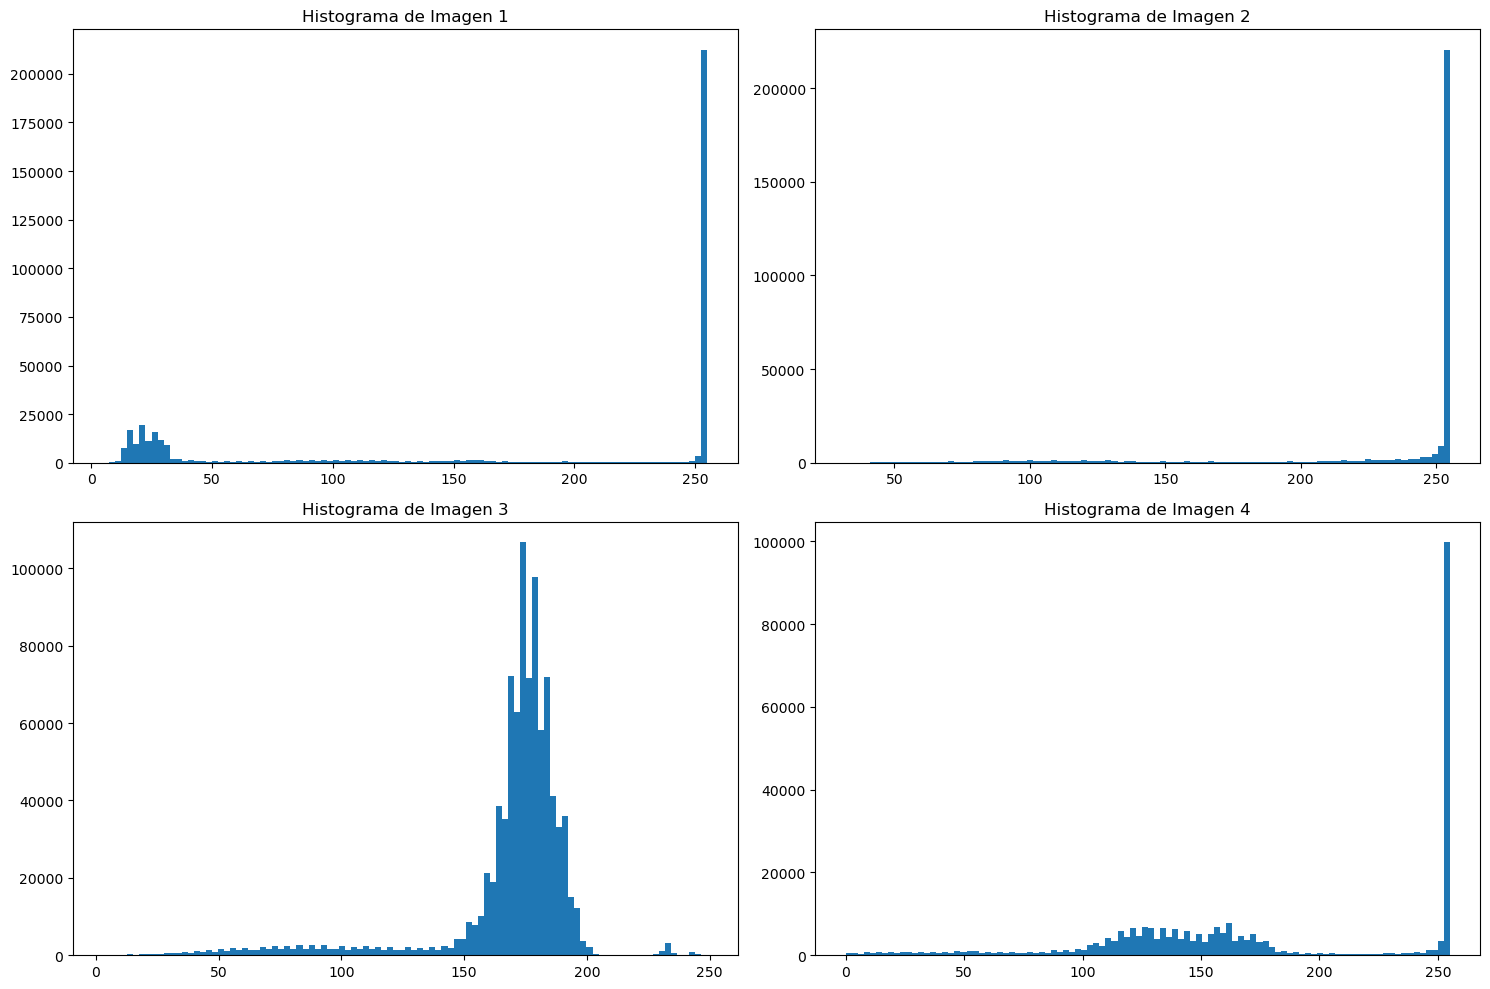

In [10]:
# 3. HISTOGRAMAS PARA DETERMINAR UMBRAL
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.hist(vectores[i], bins=100)
    plt.title(f"Histograma de {nombres[i]}")
plt.tight_layout()
plt.show()

Aplicando umbral manual de: 230


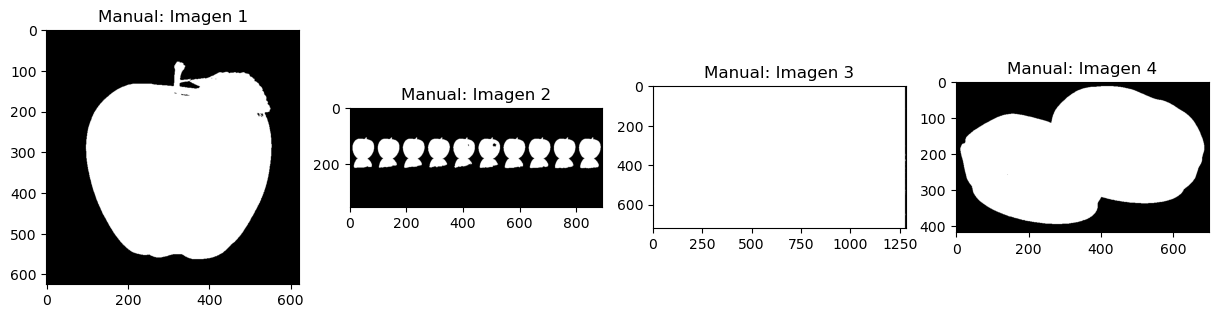

In [11]:
# 4. UMBRAL MANUAL
umbral_manual = 230
print(f"Aplicando umbral manual de: {umbral_manual}")

plt.figure(figsize=(15, 5))
for i in range(4):
    # Binarización manual (objetos oscuros sobre fondo claro)
    binaria_manual = np.uint8((grises[i] < umbral_manual) * 255)
    plt.subplot(1, 4, i+1)
    plt.imshow(binaria_manual, cmap='gray')
    plt.title(f"Manual: {nombres[i]}")
plt.show()

Umbral Otsu para Imagen 1: 144.0
Umbral Otsu para Imagen 2: 182.0
Umbral Otsu para Imagen 3: 129.0
Umbral Otsu para Imagen 4: 189.0


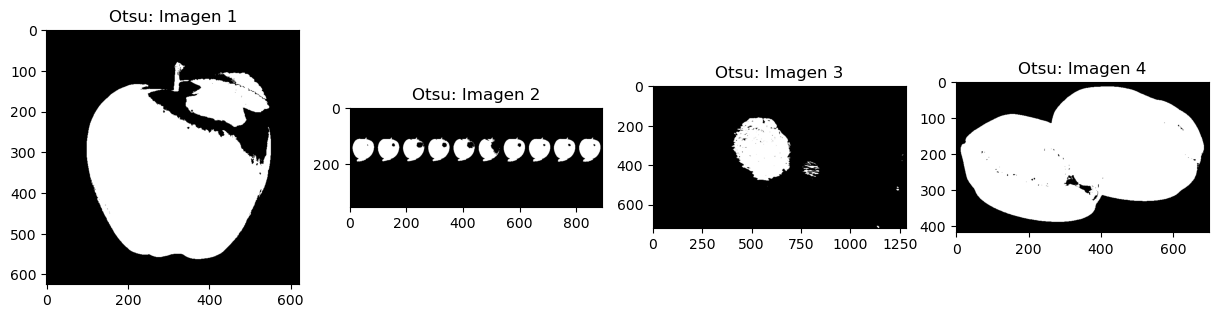

In [12]:
# 5. UMBRAL CON OTSU Y SEGMENTACIÓN/BINARIZACIÓN
binarias_otsu = []

for i in range(4):
    # Calcular umbral óptimo con Otsu
    umbral_o, _ = cv2.threshold(grises[i], 0, 255, cv2.THRESH_OTSU)
    # Aplicar binarización
    bin_otsu = np.uint8((grises[i] < umbral_o) * 255)
    binarias_otsu.append(bin_otsu)
    print(f"Umbral Otsu para {nombres[i]}: {umbral_o}")

# Visualizar resultados de Otsu
plt.figure(figsize=(15, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(binarias_otsu[i], cmap='gray')
    plt.title(f"Otsu: {nombres[i]}")
plt.show()

In [13]:
# 6. ANÁLISIS DE COMPONENTES CONECTADOS
for i in range(4):
    # salida = [num_etiquetas, etiquetas, estadisticas, centroides]
    salida = cv2.connectedComponentsWithStats(binarias_otsu[i], 4, cv2.CV_32S)
    
    num_etiquetas = salida[0]
    estadisticas = salida[2]
    
    print(f"\n--- Análisis de {nombres[i]} ---")
    print(f"Número de objetos detectados: {num_etiquetas}")
    
    # Mostrar estadísticas del primer objeto (excluyendo el fondo si es necesario)
    for j in range(1, min(num_etiquetas, 5)): # Limitado a los primeros 5 objetos
        area = estadisticas[j, cv2.CC_STAT_AREA]
        ancho = estadisticas[j, cv2.CC_STAT_WIDTH]
        alto = estadisticas[j, cv2.CC_STAT_HEIGHT]
        print(f" Objeto {j}: Área = {area}, Ancho = {ancho}, Alto = {alto}")


--- Análisis de Imagen 1 ---
Número de objetos detectados: 24
 Objeto 1: Área = 950, Ancho = 43, Alto = 72
 Objeto 2: Área = 4, Ancho = 1, Alto = 4
 Objeto 3: Área = 15, Ancho = 7, Alto = 6
 Objeto 4: Área = 17001, Ancho = 205, Alto = 134

--- Análisis de Imagen 2 ---
Número de objetos detectados: 21
 Objeto 1: Área = 4597, Ancho = 76, Alto = 84
 Objeto 2: Área = 4416, Ancho = 76, Alto = 83
 Objeto 3: Área = 4081, Ancho = 75, Alto = 83
 Objeto 4: Área = 4293, Ancho = 75, Alto = 83

--- Análisis de Imagen 3 ---
Número de objetos detectados: 34
 Objeto 1: Área = 65688, Ancho = 300, Alto = 318
 Objeto 2: Área = 44, Ancho = 8, Alto = 9
 Objeto 3: Área = 17, Ancho = 8, Alto = 5
 Objeto 4: Área = 5, Ancho = 3, Alto = 2

--- Análisis de Imagen 4 ---
Número de objetos detectados: 5
 Objeto 1: Área = 176904, Ancho = 673, Alto = 374
 Objeto 2: Área = 3, Ancho = 2, Alto = 2
 Objeto 3: Área = 5, Ancho = 3, Alto = 3
 Objeto 4: Área = 6, Ancho = 3, Alto = 2


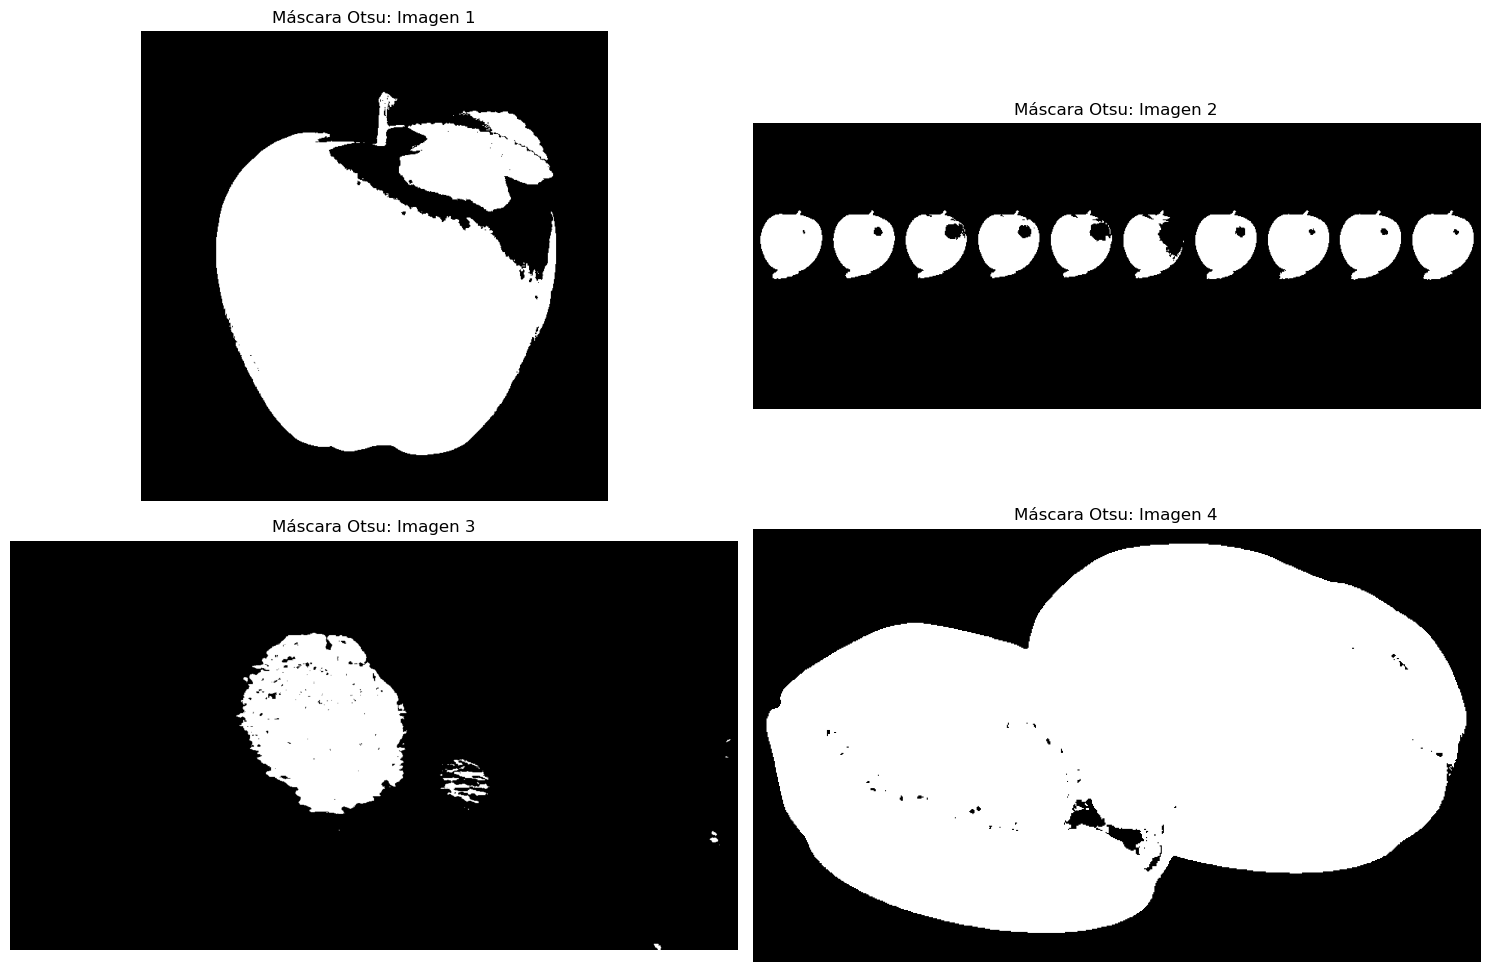

In [14]:
# 7. MÁSCARAS Y RESULTADOS FINALES
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(binarias_otsu[i], cmap='gray')
    plt.title(f"Máscara Otsu: {nombres[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [15]:
# 8. ESTADÍSTICAS FINALES Y CONCLUSIONES
print("\n--- Estadísticas Finales ---")
for i in range(4):
    num_etiquetas = cv2.connectedComponentsWithStats(binarias_otsu[i], 4, cv2.CV_32S)[0]
    print(f"{nombres[i]}: Objetos detectados = {num_etiquetas - 1}") # Restamos 1 por el fondo


--- Estadísticas Finales ---
Imagen 1: Objetos detectados = 23
Imagen 2: Objetos detectados = 20
Imagen 3: Objetos detectados = 33
Imagen 4: Objetos detectados = 4
